In [2]:
import pandas as pd

In [16]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
import numpy as np

In [12]:
from pathlib import Path

matches = list(Path.home().rglob("biosensor_data_with_target*"))
print("Found:", matches)
df = pd.read_csv(matches[0], low_memory=False)
print("Loaded rows:", len(df))

Found: [WindowsPath('C:/Users/danie/Downloads/File Path.html/biosensor_data_with_target.csv'), WindowsPath('C:/Users/danie/Downloads/File Path.html/.ipynb_checkpoints/biosensor_data_with_target-checkpoint.csv'), WindowsPath('C:/Users/danie/AppData/Roaming/Microsoft/Windows/Recent/biosensor_data_with_target.lnk')]
Loaded rows: 1000


In [13]:
sns.set_theme(style="whitegrid")
df.columns = df.columns.str.strip()
df.head()

,Age,Gender,EEG_Alpha,EEG_Beta,EEG_Theta,EEG_Delta,EEG_Gamma,Facial_Expression,Engagement_Score,Comprehension_Score,Effectiveness
0,24,female,0.525412,0.956585,0.481063,0.676958,0.509783,neutral,0.942965,0.398659,Low Effectiveness
1,21,male,0.229796,0.326634,0.852775,0.497939,0.354252,angry,0.544260,0.133230,Low Effectiveness
2,18,male,0.005359,0.280585,0.605006,0.711681,0.826611,neutral,0.926664,0.412112,Low Effectiveness
3,19,female,0.740517,0.074673,0.057530,0.124798,0.448569,surprised,0.211281,0.286925,Low Effectiveness
4,18,female,0.647880,0.358522,0.557372,0.412404,0.168969,happy,0.074020,0.236231,Low Effectiveness


In [ ]:
Q1 — What does effectiveness look like across our audience? how much actually lands

                        Count  Percent
Effectiveness                         
Low Effectiveness         747     74.7
Moderate Effectiveness    201     20.1
High Effectiveness         52      5.2


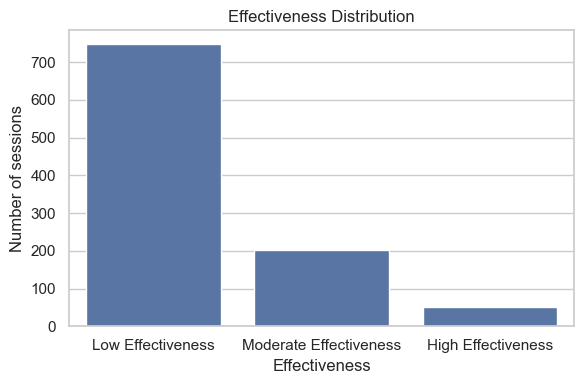

In [17]:
counts = df['Effectiveness'].value_counts()
pct = df['Effectiveness'].value_counts(normalize=True).mul(100).round(1)
summary = pd.DataFrame({'Count': counts, 'Percent': pct})
print(summary)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Effectiveness',
              order=['Low Effectiveness','Moderate Effectiveness','High Effectiveness'])
plt.title('Effectiveness Distribution')
plt.ylabel('Number of sessions')
plt.tight_layout()
plt.show()

In [ ]:
Which is sronger lever?: Comprehension or Engagement?

In [18]:
order = ['Low Effectiveness','Moderate Effectiveness','High Effectiveness']

In [19]:
print(df.groupby('Effectiveness')[['Comprehension_Score','Engagement_Score']]
        .mean().reindex(order).round(3))


                        Comprehension_Score  Engagement_Score
Effectiveness                                                
Low Effectiveness                     0.399             0.426
Moderate Effectiveness                0.727             0.692
High Effectiveness                    0.901             0.880


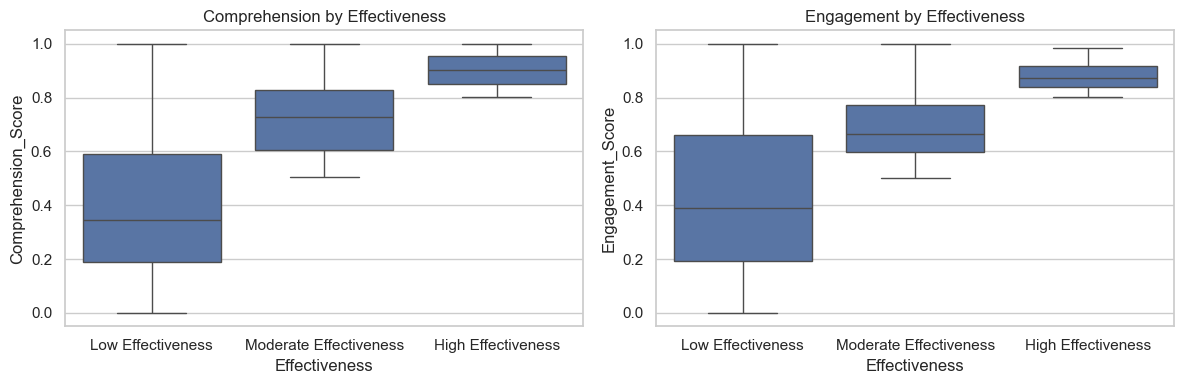

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x='Effectiveness', y='Comprehension_Score', order=order, ax=ax[0])
ax[0].set_title('Comprehension by Effectiveness')
sns.boxplot(data=df, x='Effectiveness', y='Engagement_Score', order=order, ax=ax[1])
ax[1].set_title('Engagement by Effectiveness')
plt.tight_layout(); plt.show()

In [21]:
rank = {'Low Effectiveness':0,'Moderate Effectiveness':1,'High Effectiveness':2}
df['Eff_rank'] = df['Effectiveness'].map(rank)
print(df[['Comprehension_Score','Engagement_Score']]
        .corrwith(df['Eff_rank']).round(3)
        .sort_values(ascending=False))

Comprehension_Score    0.543
Engagement_Score       0.480
dtype: float64


In [ ]:
comprehension is the high winscore

In [22]:
What measurable signal predicts that content is working?
eeg = ['EEG_Alpha','EEG_Beta','EEG_Theta','EEG_Delta','EEG_Gamma']
print(df.groupby('Effectiveness')[eeg].mean().reindex(order).round(3))


                        EEG_Alpha  EEG_Beta  EEG_Theta  EEG_Delta  EEG_Gamma
Effectiveness                                                               
Low Effectiveness           0.484     0.506      0.499      0.490      0.495
Moderate Effectiveness      0.512     0.507      0.503      0.491      0.450
High Effectiveness          0.478     0.529      0.467      0.524      0.510


In [23]:
high = df[df['Effectiveness']=='High Effectiveness'][eeg].mean()
low  = df[df['Effectiveness']=='Low Effectiveness'][eeg].mean()
gap = (high - low).sort_values(ascending=False)


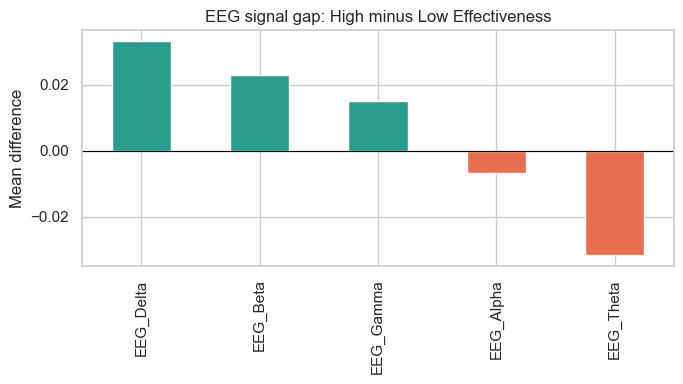

In [24]:
plt.figure(figsize=(7,4))
gap.plot(kind='bar', color=np.where(gap>0,'#2a9d8f','#e76f51'))
plt.axhline(0, color='black', lw=0.8)
plt.title('EEG signal gap: High minus Low Effectiveness')
plt.ylabel('Mean difference')
plt.tight_layout(); plt.show()

In [ ]:
Does emotional reaction relate to effectiveness?

In [25]:
ct = pd.crosstab(df['Facial_Expression'], df['Effectiveness'],
                 normalize='index').mul(100).round(1)[order]

Effectiveness      Low Effectiveness  Moderate Effectiveness  \
Facial_Expression                                              
angry                           75.7                    19.3   
happy                           71.2                    24.2   
neutral                         72.7                    21.3   
sad                             76.5                    17.5   
surprised                       77.6                    17.9   

Effectiveness      High Effectiveness  
Facial_Expression                      
angry                             5.0  
happy                             4.5  
neutral                           6.0  
sad                               6.0  
surprised                         4.5  


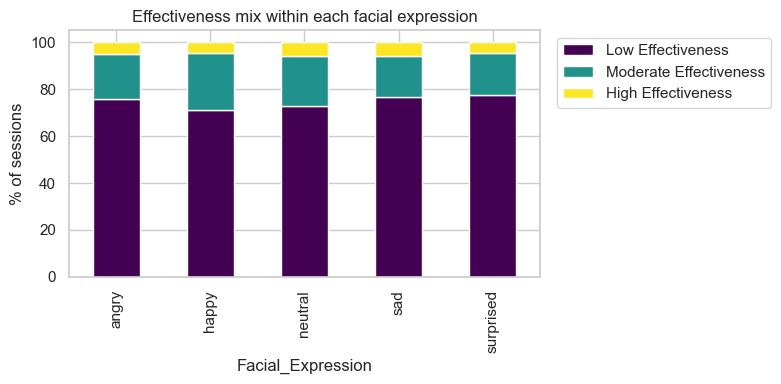

In [26]:
print(ct)

ct.plot(kind='bar', stacked=True, figsize=(8,4), colormap='viridis')
plt.title('Effectiveness mix within each facial expression')
plt.ylabel('% of sessions')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout(); plt.show()

In [28]:
df['Age_band'] = pd.cut(df['Age'], bins=[17,20,23,26],
                        labels=['18-20','21-23','24-26'])

age_gender = (df.assign(high=(df['Effectiveness']=='High Effectiveness'))
                .groupby(['Age_band','Gender'], observed=True)['high']
                .mean().mul(100).round(1).unstack())
print(age_gender)


Gender    female  male
Age_band              
18-20        4.4   7.6
21-23        5.8   4.3
24-26        6.0   2.5


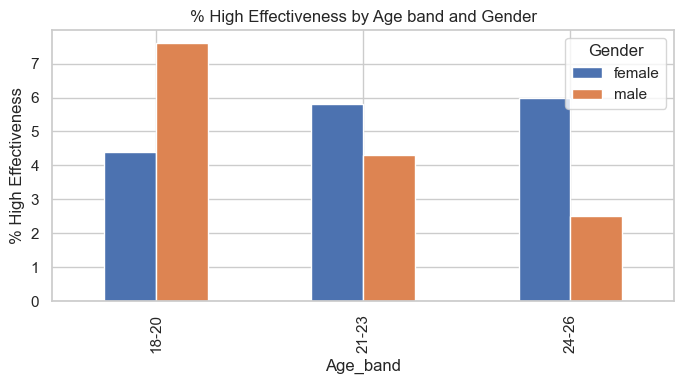

In [29]:
age_gender.plot(kind='bar', figsize=(7,4))
plt.title('% High Effectiveness by Age band and Gender')
plt.ylabel('% High Effectiveness')
plt.tight_layout();
plt.show()

In [30]:
top_eeg = gap.index[0]
lever = df[['Comprehension_Score','Engagement_Score']].corrwith(df['Eff_rank']).idxmax()

print("KEY FINDINGS FOR STAKEHOLDERS")
print("-"*40)
print(f"1. {pct.get('High Effectiveness',0)}% of sessions reached High Effectiveness.")
print(f"2. Strongest lever to optimize: {lever}.")
print(f"3. Brain signal most tied to success: {top_eeg}.")
print(f"4. See expression + demographic charts for targeting.")

KEY FINDINGS FOR STAKEHOLDERS
----------------------------------------
1. 5.2% of sessions reached High Effectiveness.
2. Strongest lever to optimize: Comprehension_Score.
3. Brain signal most tied to success: EEG_Delta.
4. See expression + demographic charts for targeting.
